In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.metrics import (classification_report, confusion_matrix, roc_curve, roc_auc_score, f1_score)

In [2]:
df = pd.read_csv("penguins.csv")

df.head()
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CulmenLength   342 non-null    float64
 1   CulmenDepth    342 non-null    float64
 2   FlipperLength  342 non-null    float64
 3   BodyMass       342 non-null    float64
 4   Species        344 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 13.6 KB


CulmenLength     2
CulmenDepth      2
FlipperLength    2
BodyMass         2
Species          0
dtype: int64

In [3]:
# czyszczenie danych
df = df.dropna()

In [4]:
df.head

<bound method NDFrame.head of      CulmenLength  CulmenDepth  FlipperLength  BodyMass  Species
0            39.1         18.7          181.0    3750.0        0
1            39.5         17.4          186.0    3800.0        0
2            40.3         18.0          195.0    3250.0        0
4            36.7         19.3          193.0    3450.0        0
5            39.3         20.6          190.0    3650.0        0
..            ...          ...            ...       ...      ...
339          55.8         19.8          207.0    4000.0        2
340          43.5         18.1          202.0    3400.0        2
341          49.6         18.2          193.0    3775.0        2
342          50.8         19.0          210.0    4100.0        2
343          50.2         18.7          198.0    3775.0        2

[342 rows x 5 columns]>

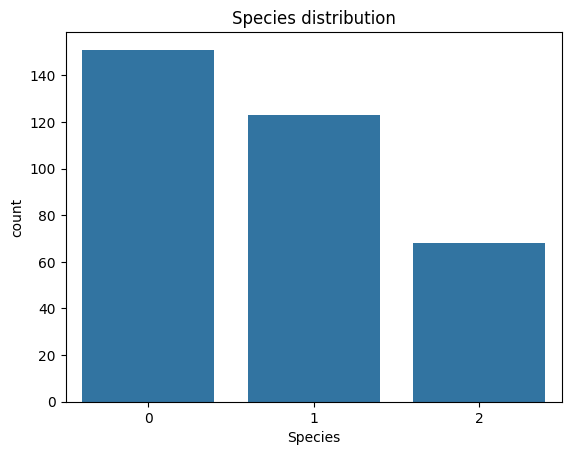

In [5]:
sns.countplot(data=df, x='Species')
plt.title("Species distribution")
plt.show()

In [6]:
df.describe()

,CulmenLength,CulmenDepth,FlipperLength,BodyMass,Species
count,342.000000,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386,0.757310
std,5.459584,1.974793,14.061714,801.954536,0.763648
min,32.100000,13.100000,172.000000,2700.000000,0.000000
25%,39.225000,15.600000,190.000000,3550.000000,0.000000
50%,44.450000,17.300000,197.000000,4050.000000,1.000000
75%,48.500000,18.700000,213.000000,4750.000000,1.000000
max,59.600000,21.500000,231.000000,6300.000000,2.000000


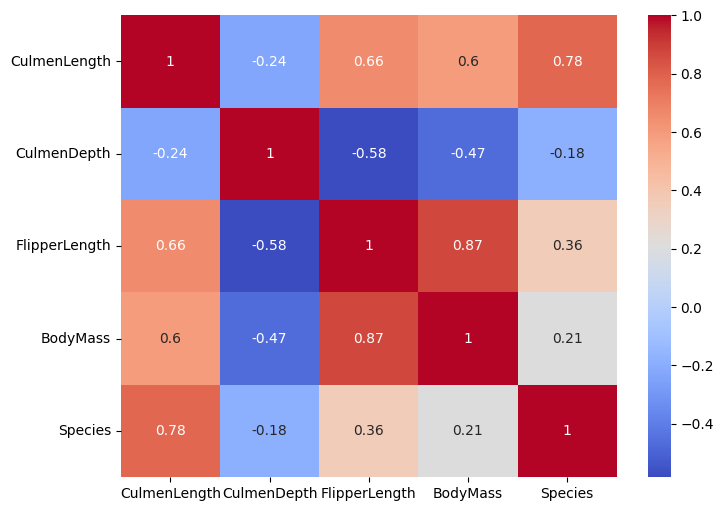

In [7]:
# Korelacje
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

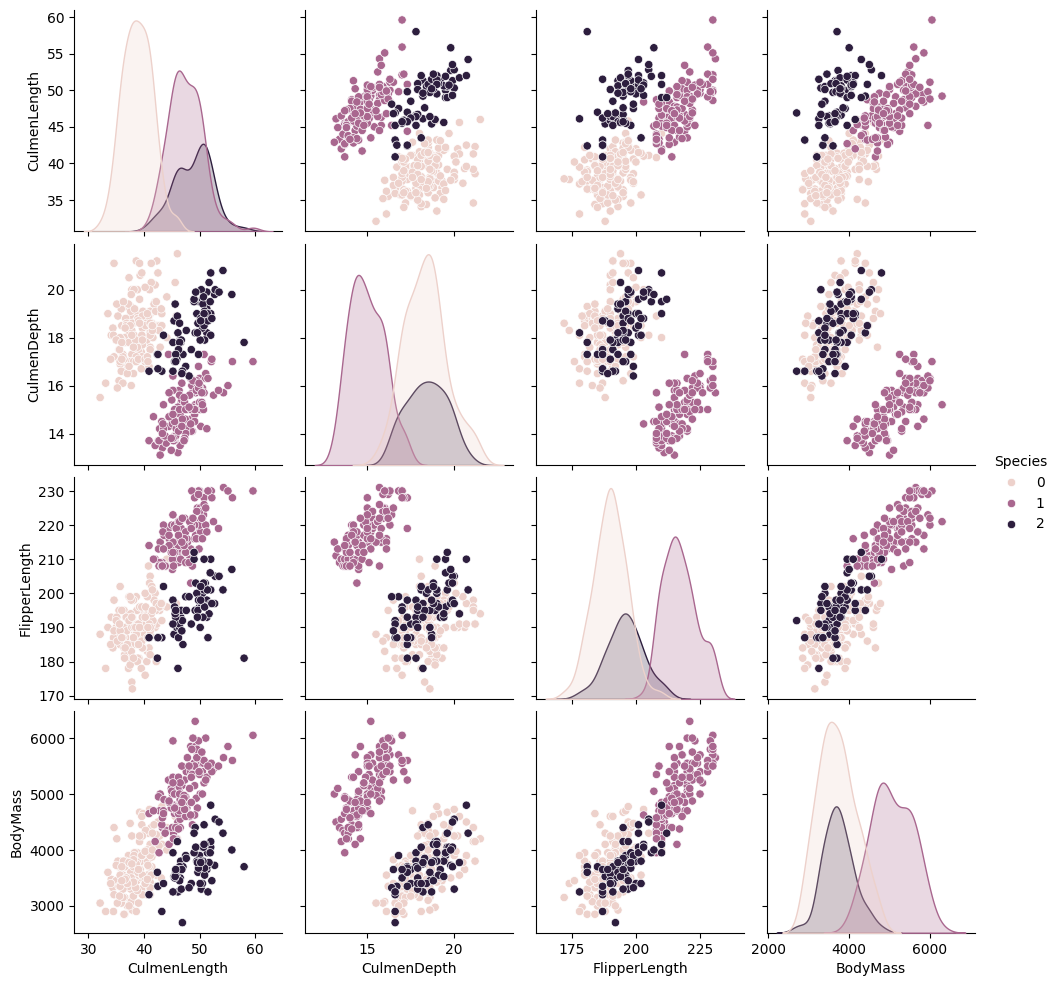

In [8]:
# Pairplot
sns.pairplot(df, hue='Species')
plt.show()

In [9]:
X = df.drop("Species", axis=1)
y = df["Species"]

In [10]:
# Trai/test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y)

# Skalowanie danych

In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Funkcja calculate_metrics

In [13]:
metrics_dataframe = pd.DataFrame(
    columns=['Model', 'F1_score', 'AUC'])

models = []
models_names = []
predictions_proba_list = []


def calculate_metrics(model, name, X_checked, y_checked):
    global metrics_dataframe

    models.append(model)
    models_names.append(name)

    predictions = model.predict(X_checked)
    predictions_proba = model.predict_proba(X_checked)

    predictions_proba_list.append(predictions_proba)

    print(classification_report(y_checked, predictions))

    # confusion matrix
    plt.figure()

    cm = confusion_matrix(y_checked, predictions)

    ax = sns.heatmap(
        cm,
        annot=True,
        cmap='Blues',
        fmt='.0f')

    ax.set_title('Confusion Matrix\n\n')
    ax.set_xlabel('\nPredicted Values')
    ax.set_ylabel('Actual Values')

    plt.show()

    # ROC Curve
    plt.figure(figsize=(6,6))
    plt.plot([0,1], [0,1], 'k--')

    for model_selected, name_selected, pred_proba in zip(
    models,
    models_names,
    predictions_proba_list):
    
        # ROC dla multiclass
        y_true_bin = pd.get_dummies(y_checked).values

        fpr, tpr, _ = roc_curve(
            y_true_bin.ravel(),
            pred_proba.ravel())

        plt.plot(
            fpr,
            tpr,
            label=name_selected)

    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.show()

    #metryki
    f1_metric = f1_score(
        y_checked,
        predictions,
        average='macro')

    auc_metric = roc_auc_score(
        y_checked,
        predictions_proba,
        multi_class='ovr')

    new_row = pd.DataFrame([{
        'Model': name,
        'F1_score': f1_metric,
        'AUC': auc_metric}])

    metrics_dataframe = pd.concat(
        [metrics_dataframe, new_row],
        ignore_index=True)

    return metrics_dataframe

# Logistic Regression

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        25
           2       1.00      1.00      1.00        14

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69



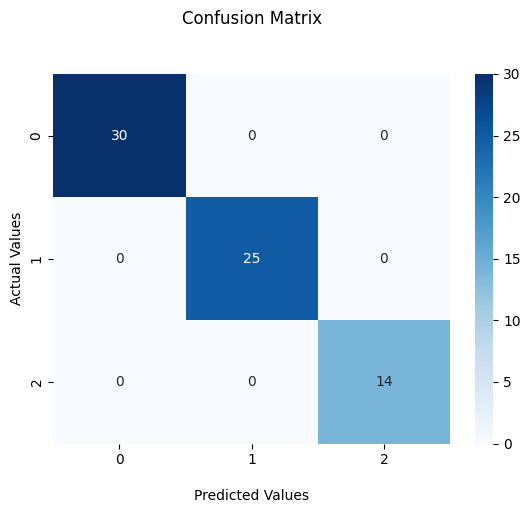

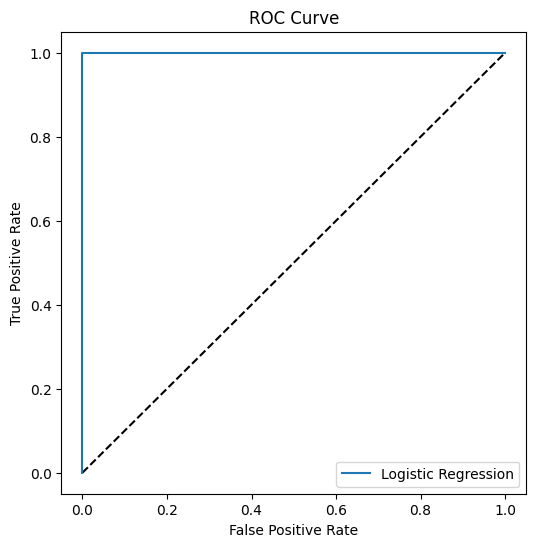

C:\Users\atrel\AppData\Local\Temp\ipykernel_3292\2464440908.py:82: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_dataframe = pd.concat(


,Model,F1_score,AUC
0,Logistic Regression,1.0,1.0


In [14]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_scaled, y_train)

calculate_metrics(
    lr_model,
    'Logistic Regression',
    X_test_scaled,
    y_test)

# KNN

              precision    recall  f1-score   support

           0       0.97      1.00      0.98        30
           1       1.00      1.00      1.00        25
           2       1.00      0.93      0.96        14

    accuracy                           0.99        69
   macro avg       0.99      0.98      0.98        69
weighted avg       0.99      0.99      0.99        69



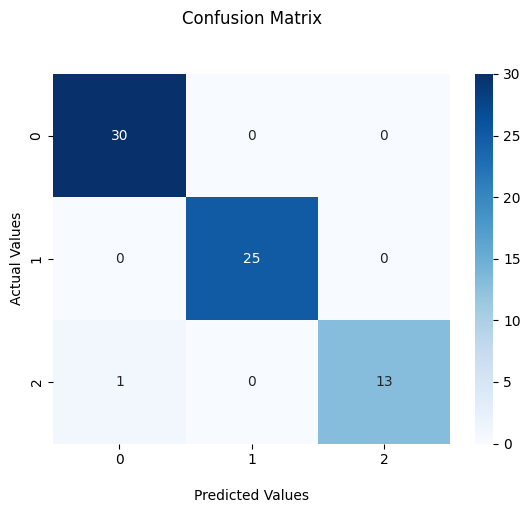

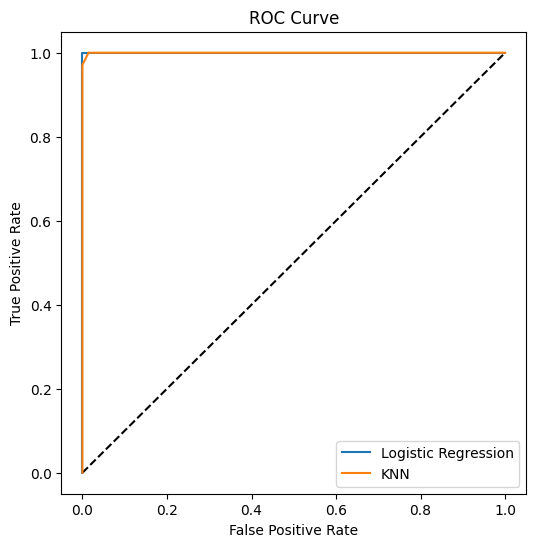

,Model,F1_score,AUC
0,Logistic Regression,1.00000,1.000000
1,KNN,0.98219,0.999641


In [15]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

calculate_metrics(
    knn_model,
    'KNN',
    X_test_scaled,
    y_test)

# Decission tree

              precision    recall  f1-score   support

           0       0.97      1.00      0.98        30
           1       1.00      1.00      1.00        25
           2       1.00      0.93      0.96        14

    accuracy                           0.99        69
   macro avg       0.99      0.98      0.98        69
weighted avg       0.99      0.99      0.99        69



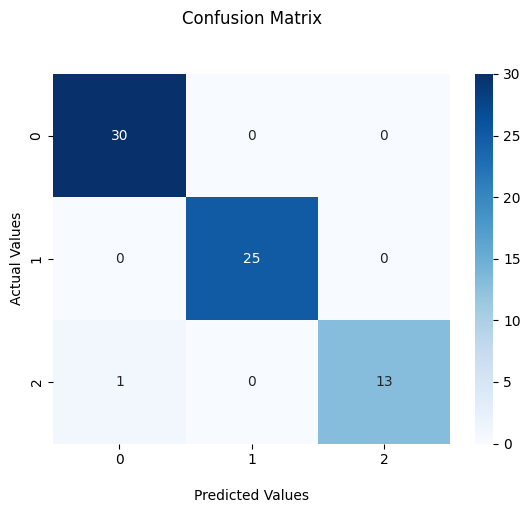

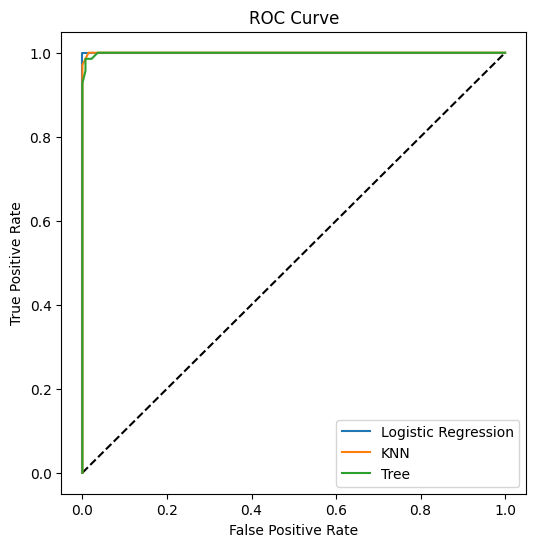

,Model,F1_score,AUC
0,Logistic Regression,1.00000,1.000000
1,KNN,0.98219,0.999641
2,Tree,0.98219,0.999282


In [16]:
from sklearn.tree import DecisionTreeClassifier

model_tree = DecisionTreeClassifier(
    max_depth=3,
    random_state=42)

model_tree.fit(X_train, y_train)

calculate_metrics(
    model_tree,
    'Tree',
    X_test,
    y_test)

# SVM

              precision    recall  f1-score   support

           0       0.94      1.00      0.97        30
           1       1.00      1.00      1.00        25
           2       1.00      0.86      0.92        14

    accuracy                           0.97        69
   macro avg       0.98      0.95      0.96        69
weighted avg       0.97      0.97      0.97        69



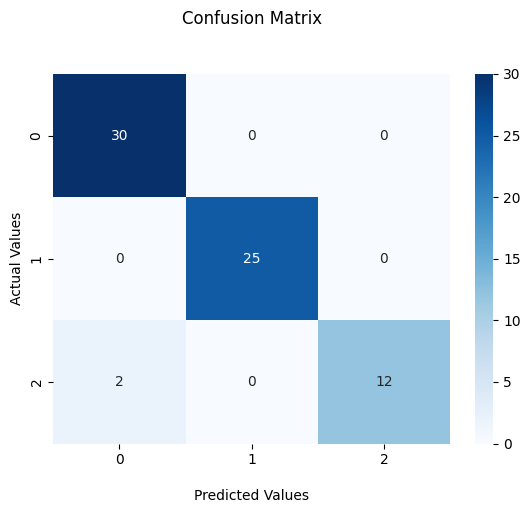

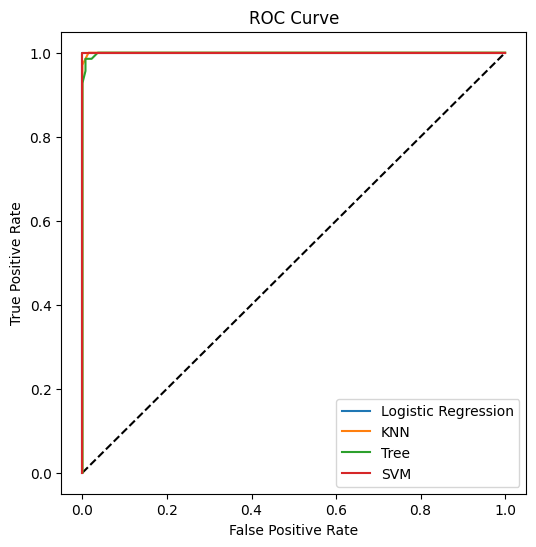

,Model,F1_score,AUC
0,Logistic Regression,1.000000,1.000000
1,KNN,0.982190,0.999641
2,Tree,0.982190,0.999282
3,SVM,0.963606,1.000000


In [17]:
from sklearn.svm import SVC

svm_model = SVC(
    probability=True)

svm_model.fit(X_train_scaled, y_train)

calculate_metrics(
    svm_model,
    'SVM',
    X_test_scaled,
    y_test)

# Random Forest

              precision    recall  f1-score   support

           0       0.97      1.00      0.98        30
           1       1.00      1.00      1.00        25
           2       1.00      0.93      0.96        14

    accuracy                           0.99        69
   macro avg       0.99      0.98      0.98        69
weighted avg       0.99      0.99      0.99        69



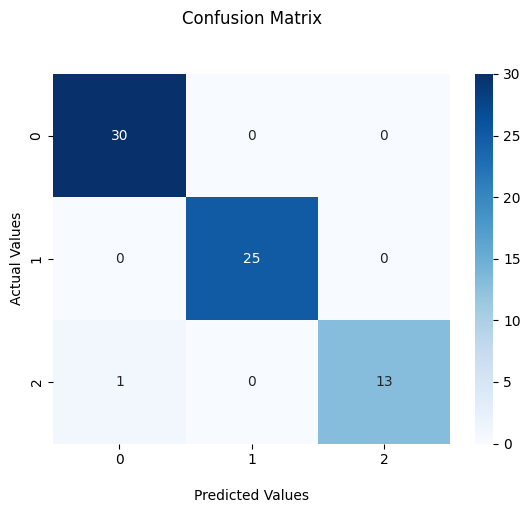

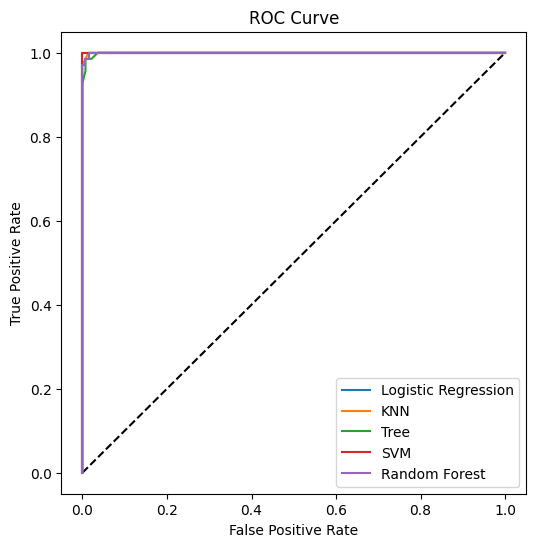

,Model,F1_score,AUC
0,Logistic Regression,1.000000,1.000000
1,KNN,0.982190,0.999641
2,Tree,0.982190,0.999282
3,SVM,0.963606,1.000000
4,Random Forest,0.982190,0.999282


In [18]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42)

rf_model.fit(X_train, y_train)

calculate_metrics(
    rf_model,
    'Random Forest',
    X_test,
    y_test)

# Boosting

              precision    recall  f1-score   support

           0       0.97      0.97      0.97        30
           1       1.00      1.00      1.00        25
           2       0.93      0.93      0.93        14

    accuracy                           0.97        69
   macro avg       0.97      0.97      0.97        69
weighted avg       0.97      0.97      0.97        69



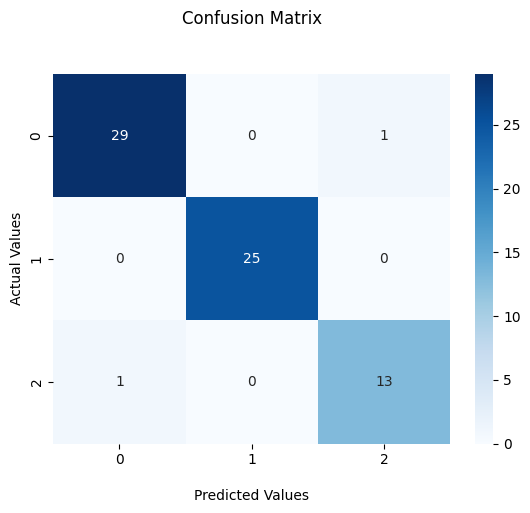

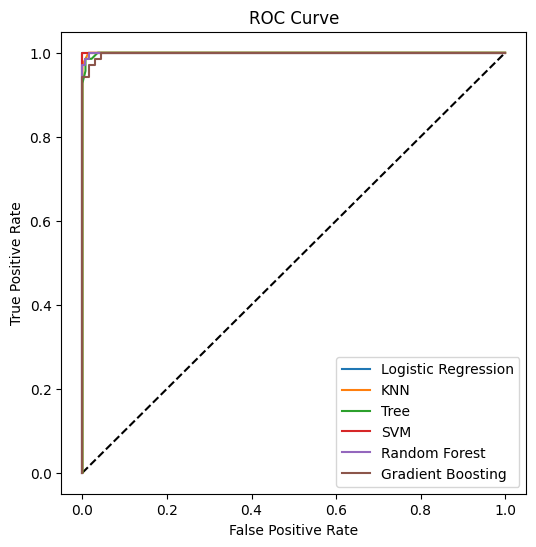

,Model,F1_score,AUC
0,Logistic Regression,1.000000,1.000000
1,KNN,0.982190,0.999641
2,Tree,0.982190,0.999282
3,SVM,0.963606,1.000000
4,Random Forest,0.982190,0.999282
5,Gradient Boosting,0.965079,0.997847


In [19]:
from sklearn.ensemble import GradientBoostingClassifier

boost_model = GradientBoostingClassifier(
    random_state=42)

boost_model.fit(X_train, y_train)

calculate_metrics(
    boost_model,
    'Gradient Boosting',
    X_test,
    y_test)

# Ensembling

              precision    recall  f1-score   support

           0       0.97      1.00      0.98        30
           1       1.00      1.00      1.00        25
           2       1.00      0.93      0.96        14

    accuracy                           0.99        69
   macro avg       0.99      0.98      0.98        69
weighted avg       0.99      0.99      0.99        69



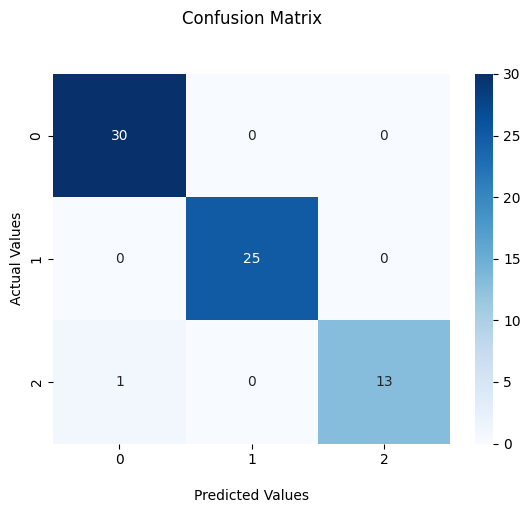

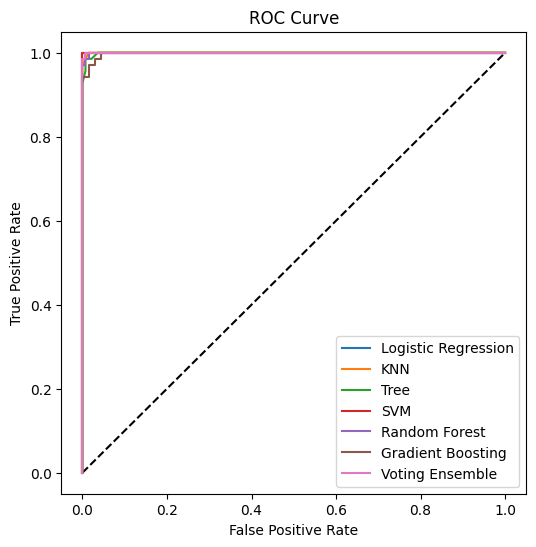

,Model,F1_score,AUC
0,Logistic Regression,1.000000,1.000000
1,KNN,0.982190,0.999641
2,Tree,0.982190,0.999282
3,SVM,0.963606,1.000000
4,Random Forest,0.982190,0.999282
5,Gradient Boosting,0.965079,0.997847
6,Voting Ensemble,0.982190,1.000000


In [20]:
from sklearn.ensemble import VotingClassifier

voting_model = VotingClassifier(
    estimators=[
        ('lr', lr_model),
        ('knn', knn_model),
        ('tree', model_tree),
        ('svm', svm_model),
        ('rf', rf_model)
    ],
    voting='soft')

voting_model.fit(X_train_scaled, y_train)

calculate_metrics(
    voting_model,
    'Voting Ensemble',
    X_test_scaled,
    y_test)

In [21]:
# Koncowa tabela wynikow

metrics_dataframe

,Model,F1_score,AUC
0,Logistic Regression,1.000000,1.000000
1,KNN,0.982190,0.999641
2,Tree,0.982190,0.999282
3,SVM,0.963606,1.000000
4,Random Forest,0.982190,0.999282
5,Gradient Boosting,0.965079,0.997847
6,Voting Ensemble,0.982190,1.000000


# Porowanie modeli

In [22]:
metrics_dataframe.sort_values(by='F1_score', ascending=False)

,Model,F1_score,AUC
0,Logistic Regression,1.000000,1.000000
1,KNN,0.982190,0.999641
2,Tree,0.982190,0.999282
4,Random Forest,0.982190,0.999282
6,Voting Ensemble,0.982190,1.000000
5,Gradient Boosting,0.965079,0.997847
3,SVM,0.963606,1.000000


In [23]:
#F1_train> F1_test ovefitting
#train=test i wysokie (ok1) dobry
#train=test i niskie (<0,5) slaby

In [24]:
print(X_train.shape)
print(X_test.shape)

(273, 4)
(69, 4)


# Zadanie 16.5

In [25]:
from sklearn.decomposition import PCA
from prettytable import PrettyTable
import datetime

# PCA - klasyfikacja

In [27]:
pca = PCA(random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

train_penguins = pd.DataFrame(np.concatenate([X_train_pca,
                          np.array(y_train).reshape(-1, 1)],
                          axis=1))

train_penguins.rename(columns = {0: 'PC1', 1: 'PC2',
                                 2: 'PC3', 3: 'PC4', 4: 'Species'},
                      inplace=True)

train_penguins[['PC1', 'PC2', 'PC3', 'PC4']] = train_penguins[['PC1', 'PC2', 'PC3', 'PC4']].astype(float)

train_penguins.corr()
train_penguins.corr()

,PC1,PC2,PC3,PC4,Species
PC1,1.000000e+00,5.686381e-17,2.266550e-16,-9.505995e-16,0.449861
PC2,5.686381e-17,1.000000e+00,-2.981033e-16,8.748870e-16,0.370574
PC3,2.266550e-16,-2.981033e-16,1.000000e+00,8.236942e-16,0.616517
PC4,-9.505995e-16,8.748870e-16,8.236942e-16,1.000000e+00,0.060144
Species,4.498607e-01,3.705740e-01,6.165168e-01,6.014422e-02,1.000000


In [28]:
# porownanie klasyfikacji

def train_and_check(Xtrain, Xtest, ytrain, ytest):
    classifier = LogisticRegression(max_iter=100000)

    start = datetime.datetime.now()
    classifier.fit(Xtrain, ytrain)
    end = datetime.datetime.now()

    time = (end - start).microseconds
    evaluation = np.round(classifier.score(Xtest, ytest), 4)

    return evaluation, time

In [29]:
results = PrettyTable(['Model',
                       'Dokładność',
                       'Czas trenowania (microseconds)'])

not_scaled_data = train_and_check(X_train, X_test, y_train, y_test)
results.add_row(['Nieskalowane dane', not_scaled_data[0], not_scaled_data[1]])

scaled_data = train_and_check(X_train_scaled, X_test_scaled, y_train, y_test)
results.add_row(['Skalowane dane', scaled_data[0], scaled_data[1]])

PC4_data = train_and_check(X_train_pca, X_test_pca, y_train, y_test)
results.add_row(['4 PC', PC4_data[0], PC4_data[1]])

PC3_data = train_and_check(X_train_pca[:, :3], X_test_pca[:, :3], y_train, y_test)
results.add_row(['3 PC', PC3_data[0], PC3_data[1]])

PC2_data = train_and_check(X_train_pca[:, :2], X_test_pca[:, :2], y_train, y_test)
results.add_row(['2 PC', PC2_data[0], PC2_data[1]])

PC1_data = train_and_check(X_train_pca[:, :1], X_test_pca[:, :1], y_train, y_test)
results.add_row(['1 PC', PC1_data[0], PC1_data[1]])

print(results)

+-------------------+------------+--------------------------------+
|       Model       | Dokładność | Czas trenowania (microseconds) |
+-------------------+------------+--------------------------------+
| Nieskalowane dane |   0.9855   |             774053             |
|   Skalowane dane  |    1.0     |              4116              |
|        4 PC       |    1.0     |              4145              |
|        3 PC       |    1.0     |              5221              |
|        2 PC       |   0.942    |              5746              |
|        1 PC       |   0.9275   |              4113              |
+-------------------+------------+--------------------------------+


In [30]:
# PCA dla problemu regresji - przewidujemy BodyMass

X_reg = df.drop('BodyMass', axis=1).copy()
y_reg = df['BodyMass'].copy()

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

scaler_reg = StandardScaler()

X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

pca_reg = PCA(random_state=42)

X_train_reg_pca = pca_reg.fit_transform(X_train_reg_scaled)
X_test_reg_pca = pca_reg.transform(X_test_reg_scaled)

In [31]:
train_penguins_reg = pd.DataFrame(np.concatenate([X_train_reg_pca,
                          np.array(y_train_reg).reshape(-1, 1)],
                          axis=1))

train_penguins_reg.rename(columns = {0: 'PC1', 1: 'PC2',
                                     2: 'PC3', 3: 'PC4', 4: 'BodyMass'},
                          inplace=True)

train_penguins_reg[['PC1', 'PC2', 'PC3', 'PC4']] = train_penguins_reg[['PC1', 'PC2', 'PC3', 'PC4']].astype(float)

train_penguins_reg.corr()

,PC1,PC2,PC3,PC4,BodyMass
PC1,1.000000e+00,-3.566686e-16,1.493524e-16,6.361218e-16,0.689096
PC2,-3.566686e-16,1.000000e+00,2.738390e-16,-4.698917e-16,-0.337680
PC3,1.493524e-16,2.738390e-16,1.000000e+00,-2.984810e-16,0.457928
PC4,6.361218e-16,-4.698917e-16,-2.984810e-16,1.000000e+00,0.034947
BodyMass,6.890960e-01,-3.376798e-01,4.579283e-01,3.494688e-02,1.000000


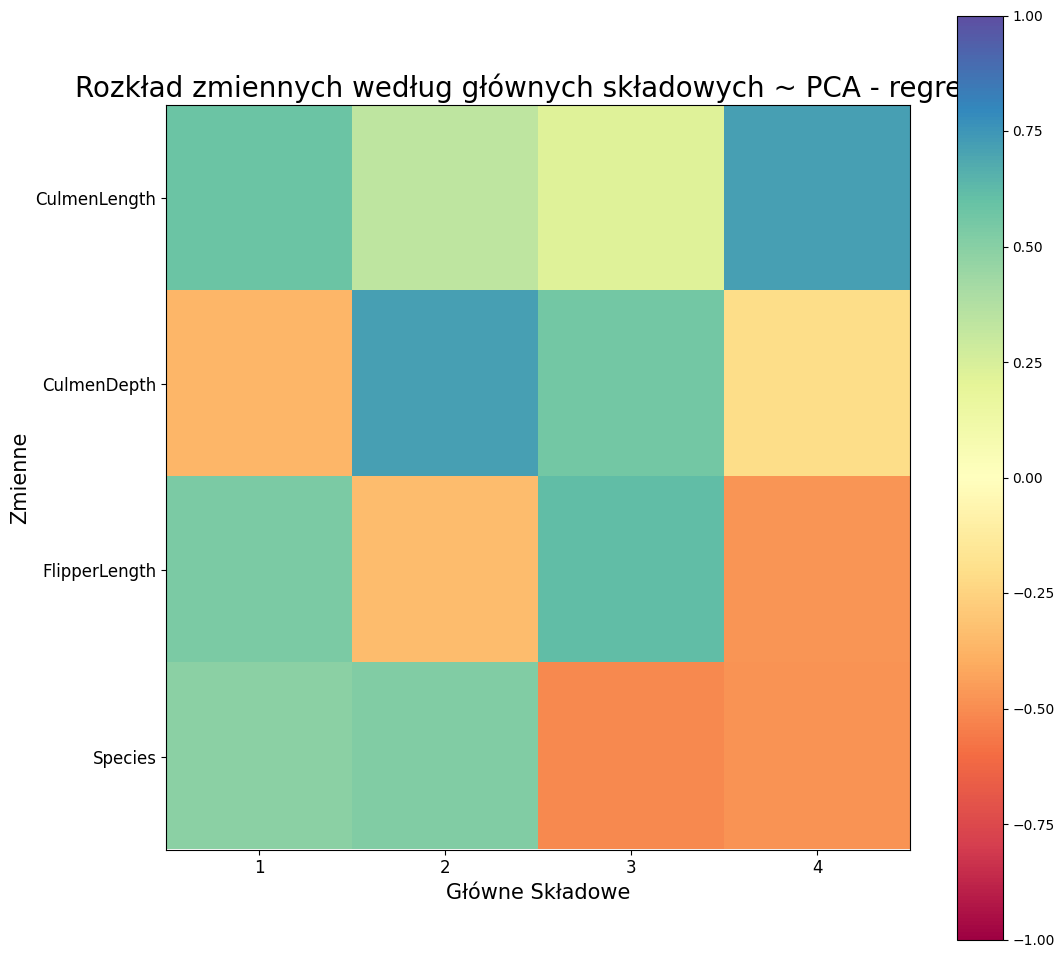

In [32]:
fig, ax = plt.subplots(figsize=(12, 12))

plt.imshow(pca_reg.components_.T, cmap='Spectral', vmin=-1, vmax=1)
plt.yticks(range(len(X_train_reg.columns)), X_train_reg.columns, fontsize=12)
plt.xticks(range(4), range(1, 5), fontsize=12)

plt.xlabel('Główne Składowe', fontsize=15)
plt.ylabel('Zmienne', fontsize=15)
plt.title('Rozkład zmiennych według głównych składowych ~ PCA - regresja', fontsize=20)

plt.colorbar()
plt.show()

In [33]:
from sklearn.linear_model import LinearRegression

def train_and_check_regression(Xtrain, Xtest, ytrain, ytest):
    model = LinearRegression()

    start = datetime.datetime.now()
    model.fit(Xtrain, ytrain)
    end = datetime.datetime.now()

    time = (end - start).microseconds
    evaluation = np.round(model.score(Xtest, ytest), 4)

    return evaluation, time

In [34]:
results_reg = PrettyTable(['Model',
                           'R2',
                           'Czas trenowania (microseconds)'])

not_scaled_data = train_and_check_regression(X_train_reg, X_test_reg, y_train_reg, y_test_reg)
results_reg.add_row(['Nieskalowane dane', not_scaled_data[0], not_scaled_data[1]])

scaled_data = train_and_check_regression(X_train_reg_scaled, X_test_reg_scaled, y_train_reg, y_test_reg)
results_reg.add_row(['Skalowane dane', scaled_data[0], scaled_data[1]])

PC4_data = train_and_check_regression(X_train_reg_pca, X_test_reg_pca, y_train_reg, y_test_reg)
results_reg.add_row(['4 PC', PC4_data[0], PC4_data[1]])

PC3_data = train_and_check_regression(X_train_reg_pca[:, :3], X_test_reg_pca[:, :3], y_train_reg, y_test_reg)
results_reg.add_row(['3 PC', PC3_data[0], PC3_data[1]])

PC2_data = train_and_check_regression(X_train_reg_pca[:, :2], X_test_reg_pca[:, :2], y_train_reg, y_test_reg)
results_reg.add_row(['2 PC', PC2_data[0], PC2_data[1]])

PC1_data = train_and_check_regression(X_train_reg_pca[:, :1], X_test_reg_pca[:, :1], y_train_reg, y_test_reg)
results_reg.add_row(['1 PC', PC1_data[0], PC1_data[1]])

print(results_reg)

+-------------------+--------+--------------------------------+
|       Model       |   R2   | Czas trenowania (microseconds) |
+-------------------+--------+--------------------------------+
| Nieskalowane dane | 0.8228 |             12671              |
|   Skalowane dane  | 0.8228 |               0                |
|        4 PC       | 0.8228 |              2044              |
|        3 PC       | 0.8213 |              1086              |
|        2 PC       |  0.57  |              998               |
|        1 PC       | 0.5388 |              997               |
+-------------------+--------+--------------------------------+
